In [30]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
orders = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\Real world data analyctics psql\orders_large.csv")

customers = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\Real world data analyctics psql\customers_large.csv")

products = pd.read_csv(r"C:\Users\Ameet Computer\OneDrive\Pictures\Camera Roll\Real world data analyctics psql\products_large.csv")


In [5]:
orders.head()

,order_id,customer_id,employee_id,product_id,quantity,order_date
0,1,235,57,15,4,2024-03-04
1,2,345,83,20,7,2025-10-21
2,3,534,66,5,7,2025-09-19
3,4,860,22,7,7,2025-09-01
4,5,797,20,18,7,2024-08-26


In [7]:
orders.describe()

,order_id,customer_id,employee_id,product_id,quantity
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,503.979600,50.403800,25.600800,5.055000
std,2886.89568,288.409138,28.836839,14.457729,2.556996
min,1.00000,1.000000,1.000000,1.000000,1.000000
25%,2500.75000,252.000000,25.000000,13.000000,3.000000
50%,5000.50000,508.000000,51.000000,26.000000,5.000000
75%,7500.25000,754.250000,76.000000,38.000000,7.000000
max,10000.00000,1000.000000,100.000000,50.000000,9.000000


In [8]:
customers.describe()

,customer_id
count,1000.000000
mean,500.500000
std,288.819436
min,1.000000
25%,250.750000
50%,500.500000
75%,750.250000
max,1000.000000


In [9]:
orders.isnull().sum()

order_id       0
customer_id    0
employee_id    0
product_id     0
quantity       0
order_date     0
dtype: int64

In [10]:
customers.isnull().sum()

customer_id      0
customer_name    0
city             0
customer_type    0
dtype: int64

In [12]:
orders.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [13]:
customers.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [21]:
df=orders.merge(customers,on="customer_id",how="left")
df=orders.merge(products,on=("product_id"),how="left")

In [15]:
df.groupby("customer_name")["quantity"].sum()

customer_name
Customer_1       66
Customer_10      43
Customer_100     43
Customer_1000    52
Customer_101     65
                 ..
Customer_995     28
Customer_996     56
Customer_997     37
Customer_998     19
Customer_999     51
Name: quantity, Length: 1000, dtype: int64

In [24]:
df["sales"] = df["quantity"] * df["price"]


,order_id,customer_id,employee_id,product_id,quantity,order_date,product_name,category,price,sales
0,1,235,57,15,4,2024-03-04,Product_15,Electronics,433,1732
1,2,345,83,20,7,2025-10-21,Product_20,Electronics,705,4935
2,3,534,66,5,7,2025-09-19,Product_5,Home,1445,10115
3,4,860,22,7,7,2025-09-01,Product_7,Office,1708,11956
4,5,797,20,18,7,2024-08-26,Product_18,Accessories,1331,9317


In [25]:
df["sales"].sum()

np.int64(47279460)

In [27]:
df.groupby("customer_id")["sales"].sum().sort_values(ascending=False).head()

customer_id
314    117545
658    115795
700    113459
726    112483
728    109615
Name: sales, dtype: int64

In [28]:
df["quantity"].mean()

np.float64(5.055)

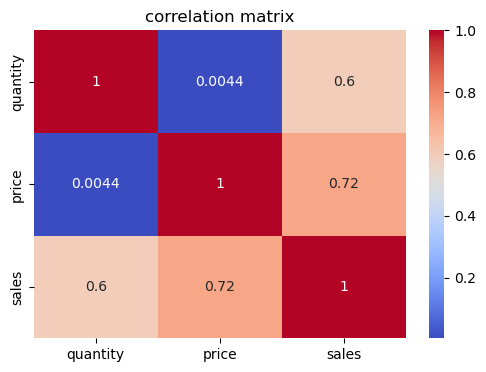

In [32]:
#correlation 


plt.figure(figsize=(6,4))
corr = df[["quantity","price","sales"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("correlation matrix")
plt.show()


In [33]:
df["sales"].skew()
df["sales"].kurt()

np.float64(0.2794809472151285)

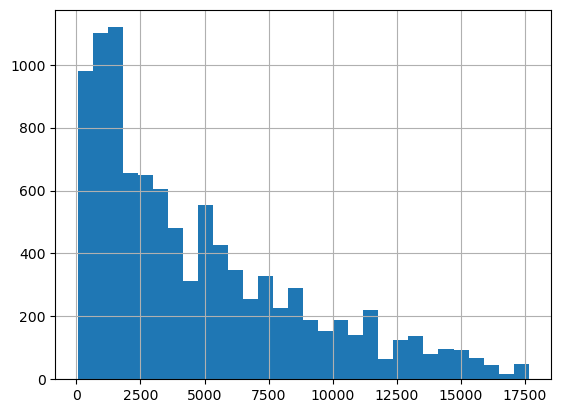

In [34]:
df["sales"].hist(bins=30)
plt.title=("sales distribution skewness")
plt.xlabel=("sales")
plt.ylabel=("frequency")
plt.show()

In [36]:
df["sales"].var()
df["sales"].std()

4062.0246888640786

In [40]:
# z score (outlier detection)
df["z_score"] = stats.zscore(df["sales"])
outliers = df[df["z_score"].abs() > 2.5]
outliers.head(10)

,order_id,customer_id,employee_id,product_id,quantity,order_date,product_name,category,price,sales,z_score
45,46,129,76,38,9,2024-01-30,Product_38,Office,1681,15129,2.560687
68,69,112,100,39,8,2024-07-17,Product_39,Accessories,1947,15576,2.670736
84,85,437,10,38,9,2025-07-26,Product_38,Office,1681,15129,2.560687
202,203,573,7,46,9,2024-08-26,Product_46,Office,1779,16011,2.777831
272,273,848,95,38,9,2024-05-03,Product_38,Office,1681,15129,2.560687
277,278,729,78,39,9,2024-04-18,Product_39,Accessories,1947,17523,3.150078
302,303,760,51,16,9,2025-07-09,Product_16,Accessories,1768,15912,2.753458
309,310,917,45,23,8,2024-11-25,Product_23,Office,1960,15680,2.696340
342,343,327,15,7,9,2025-10-21,Product_7,Office,1708,15372,2.620512
356,357,177,95,38,9,2025-03-09,Product_38,Office,1681,15129,2.560687


In [42]:
#outliers

Q1=df["sales"].quantile(0.25)
Q3=df["sales"].quantile(0.75)

IQR = Q3 - Q1

Outliers = df[(df["sales"] < Q1 - 1.5 * IQR) | (df["sales"] > Q3 + 1.5 * IQR)]

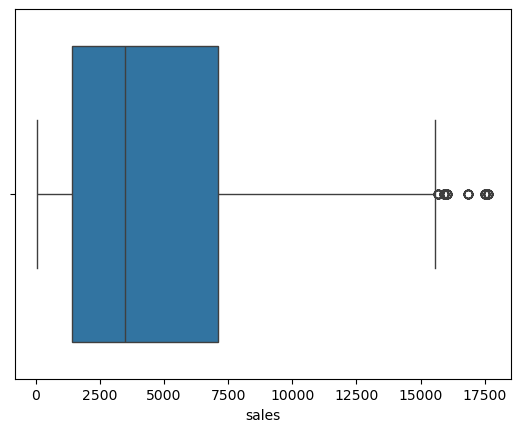

In [43]:
sns.boxplot(x=df["sales"])
plt.show()

In [44]:
df["sales_log"] = np.log1p(df["sales"])

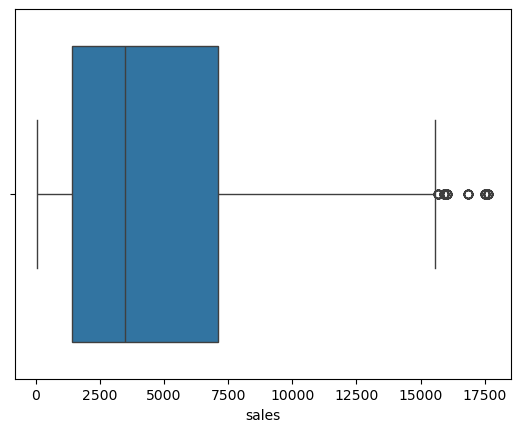

In [45]:
sns.boxplot(x=df["sales"])
plt.show()

In [47]:
#CORRECT OUTLIERS

median = df["sales"].median()

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df.loc[df["sales"] > upper, "sales"] = median
df.loc[df["sales"] < lower, "sales"] = median

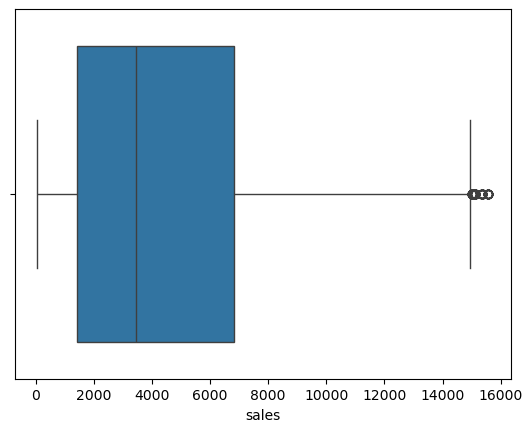

In [48]:
sns.boxplot(x=df["sales"])
plt.show()

In [50]:
Q1 = df["sales"].quantile(0.25)
Q3 = df["sales"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [51]:
df["sales_capped"] = df["sales"].clip(lower, upper)

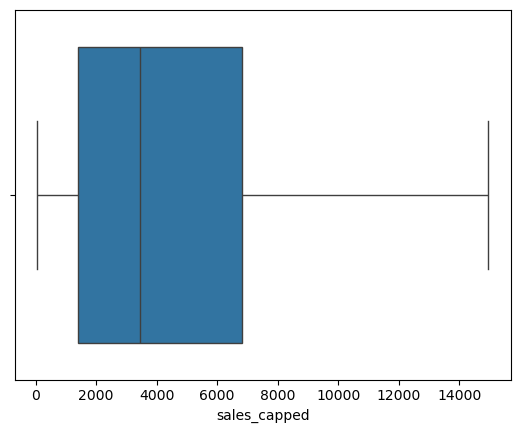

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df["sales_capped"])
plt.show()